# 상관관계, 상관계수

In [5]:
# # _corr_01.py
# 상관관계, 상관계수, 공분산

import os
import numpy as np
import matplotlib.pyplot as plt

### 상관계수, 난수 $ x, y $ 생성함수 정의
$$ \rho_{x,y} = {cov(x,y) \over \sigma_x \sigma_y } $$

In [6]:
# numpy as np 필수
# 상관관계에 딱 맞는 계열 쌍 생성

def rngd_xy_rho(rho, n_pop, seed) :
    rng = np.random.default_rng(seed)  # 난수생성 준비. 객체. 크기나 종류, 이런 것 미정.
                                       # 이 상대는 계속 동일한 자료를 생성. 루프 밖으로 내는 아이디어?

    # 3.1. 난수 생성: z1, z2
    z1 = rng.normal(size=n_pop)
    z2 = rng.normal(size=n_pop)

    # 3.2. 표준화: 결국 표준정규변수 z1, z2, 서로 독립인 상태. 상관계수 0.
    z1 = (z1 - z1.mean()) / z1.std(ddof=1)
    z2 = (z2 - z2.mean()) / z2.std(ddof=1)

    # 3.3. 직교화 (Gram-Schmidt)
    z2 = z2 - np.dot(z1, z2) / np.dot(z1, z1) * z1
    z2 = z2 / z2.std(ddof=1)

    # 3.4. 원하는 상관계수 생성, x, y는 정확히 모 상관계수로 생성.
    x = z1
    y = rho * z1 + np.sqrt(1 - rho**2) * z2

    # 3.5. 다시 표준화, x, y는 정확히 상관계수에서 생성된 변수. 표준화된 변수.
    #   이것이 모의실험에 투입되는 변수임.
    #   모상관계수가 그렇다고 해도 표본 상관계수는 차이날 수 있음. 이것을 극복하는 것.
    #   교과서에 보여줄 수 있는 그림. 그것임.
    x = (x - x.mean()) / x.std(ddof=1)
    y = (y - y.mean()) / y.std(ddof=1)

    r = np.corrcoef(x, y)[0, 1]  # 실험 상관계수, 이론 값과 일치하도록.
    return x, y


### 각 상관관계에 대해 난수를 생성하고, 그래프로 표시, 비교

In [9]:
# 필요한 파라메타는 아래 별도 셀에서 지정.
    # seed = 135678942
    # n_pop = 100
    # sub_c = 3
    # sub_r = 3
    # nfig = sub_r*sub_c

def main():
# 1. 데이터 준비. 읽기. 생성.
# 1.1. 상관계수, 자료 생성에 투입 예정, 9가지 경우.
# -- 0.1부터 시작해서 0.9까지, nfig 갯수
    target_rs = np.linspace(0.1, 0.9, nfig) # 상관계수, 뒤에 사용할 값이네, 9개.

# 2. 목표 구성. 그래프 생성.
# 차트 구성, 서브 차트 3*3=9개,
# -- 10*10인치 그림판, 부속 그림 3*3 9개 공간,
# -- fig는 전체 그림판,
# -- axes는 작은 캔버스
    fig, axes = plt.subplots(sub_r, sub_c, figsize=(8, 8))

# 3. 목표에 적합한 자료 구성, 연산 등.
#  조건에 맞는 난수 생성, 즉 상관계수 크기에 따른 난수쌍 생성
#    rng = np.random.default_rng(seed)  # 난수생성 준비. 객체. 크기나 종류, 이런 것 미정.
#  for 조건문. 반복.
#   target_rs에 나열된 상관관계 값은 rho, 나열 순서는 ax로 받음.
    for ax, rho in zip(axes.flat, target_rs):

    # target_r은 정확한 모 상관계수가 나오도록 구성함.
    # 독립 난수 생성, 모 상관계수에 따르는 자료 생성. 를 그대로 보여주는 설정.
    # 모의실험에 설정된 상관계수가 모상관계수가 되게끔 재현하는 방법.
        x, y = rngd_xy_rho(rho, n_pop, seed)  # 상관관계를 반영한 난수생성, 함수로 앞으로 뺴 내었음.

    # 3.6. 그림 그리기.
    #  반복 조건문의 서브플롯, axes (3*3),
    #  for 어쩌구 in 어쩌구.

        ax.scatter(
            x, y,
            s=25,
            marker='o',
            facecolor='none',
            edgecolor='black',
            linewidths=1.5
            #color='black', 요건 점으로 할 때.
            #alpha=0.7
            )
        ax.set_title(f"rho = {rho:.3f}", fontsize=11)

        ax.set_xlim(-3.5, 3.5)
        ax.set_ylim(-3.5, 3.5)
        ax.set_aspect('equal')
        ax.set_xticks([])
        ax.set_yticks([])

# 4. 결과물 디스플레이
#  for 에서 생성된 일련의 ax는 axes 개체를 그린 것.
#  전체 그림은 fig로 지정된 것.
#  이미 알고 있는 개체 fig를 보여주라는 명령.
    plt.tight_layout()
    plt.show()


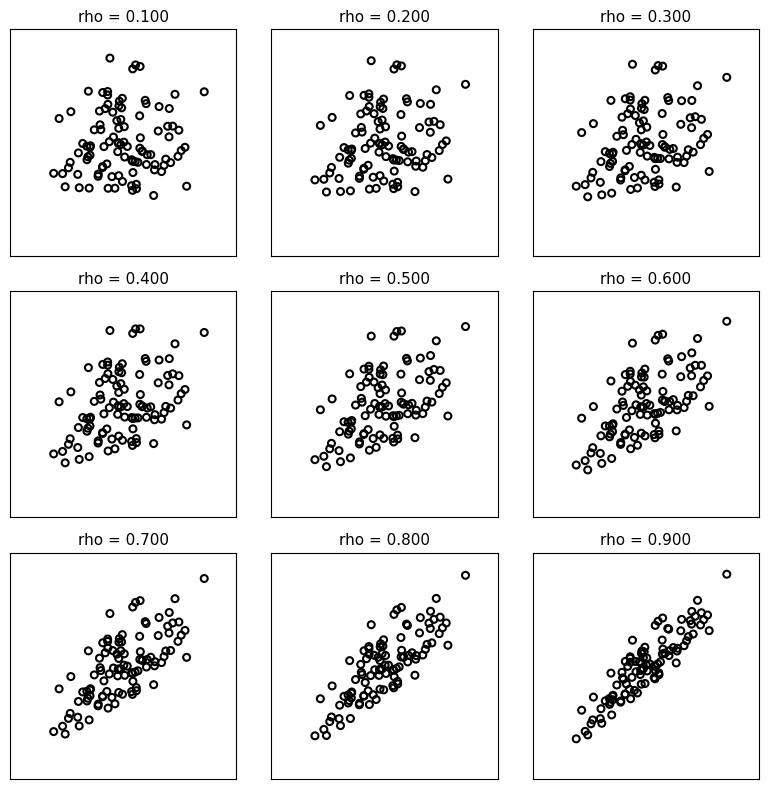

In [11]:
# 7. 메인() 일괄 실행. 이런 식으로 하려면, 위 단추 Run All 클릭.
# 이미 위 셀들이 실행된 적이 있으면, 이 셀만 실행하면 OK
# 그렇지 않으면, 모든 셀 일괄 실행. 즉 Run All

if __name__ == "__main__":
    # 실행 전 설정
    seed = 12348215
    n_pop = 100  # 모집단 크기인 셈. 샘플 사이즈, 생성할 관측 갯수.
    sub_c = 3
    sub_r = 3
    nfig = sub_r*sub_c


    main()
